In [1]:
import os
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from random import seed, randrange, sample
import math
import numpy as np
from math import sqrt, exp
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
import random
from tqdm import tqdm

In [2]:
df = pd.read_excel("Data for SPSS.xlsx")
df.head()

,Faculty,Gender,Academic year,Age group,Learning time before COVID-19,Learning time during COVID-19,No. of Siblings,Location of residence,Source of tuition fees,Cumulative average (GPA),...,TM2,TM3,HS1,HS2,HS3,HS4,SE1,SE2,SE3,SE4
0,5,1,2,1,2,2,1,3,1,1,...,3,4,2,4,4,3,4,4,3,4
1,5,1,1,1,1,1,4,3,2,1,...,5,5,5,5,5,2,2,2,2,4
2,5,1,2,1,2,1,2,3,1,1,...,4,4,2,4,4,3,3,4,4,4
3,8,1,3,2,2,2,3,3,1,1,...,4,4,4,4,4,4,4,4,4,4
4,6,1,2,2,2,1,3,2,1,2,...,2,3,5,5,5,5,4,4,1,2


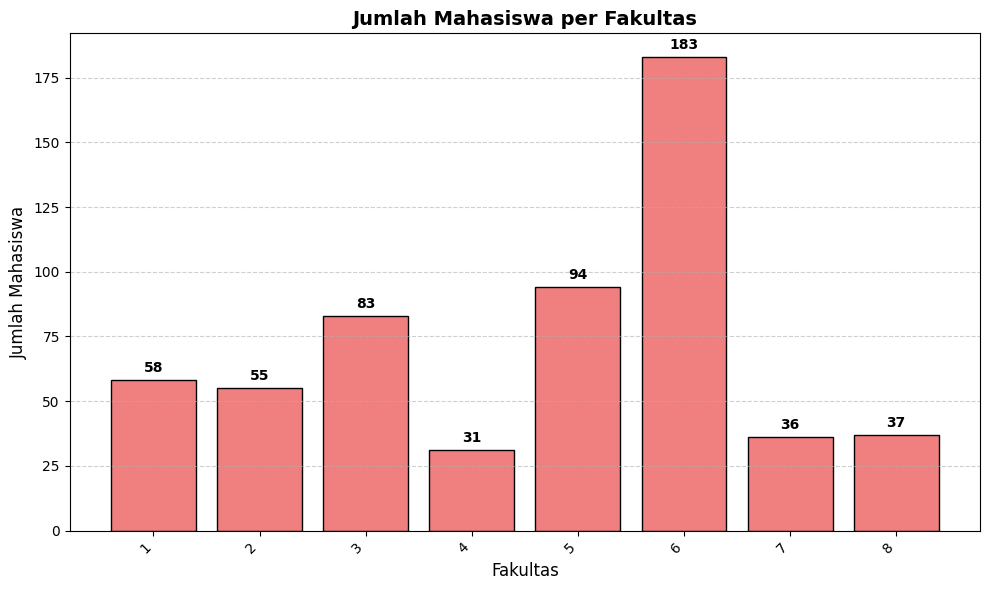

=== Jumlah Mahasiswa per Fakultas ===
   Faculty  Jumlah Mahasiswa
0        6               183
1        5                94
2        3                83
3        1                58
4        2                55
5        8                37
6        7                36
7        4                31


In [3]:
# jumlah mahasiswa/fakultas
faculty_counts = df['Faculty'].value_counts().reset_index()
faculty_counts.columns = ['Faculty', 'Jumlah Mahasiswa']

plt.figure(figsize=(10, 6))
bars = plt.bar(faculty_counts['Faculty'], faculty_counts['Jumlah Mahasiswa'], color='lightcoral', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, yval + 2,   # posisi teks di atas batang
        int(yval), ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.title('Jumlah Mahasiswa per Fakultas', fontsize=14, fontweight='bold')
plt.xlabel('Fakultas', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("=== Jumlah Mahasiswa per Fakultas ===")
print(faculty_counts)

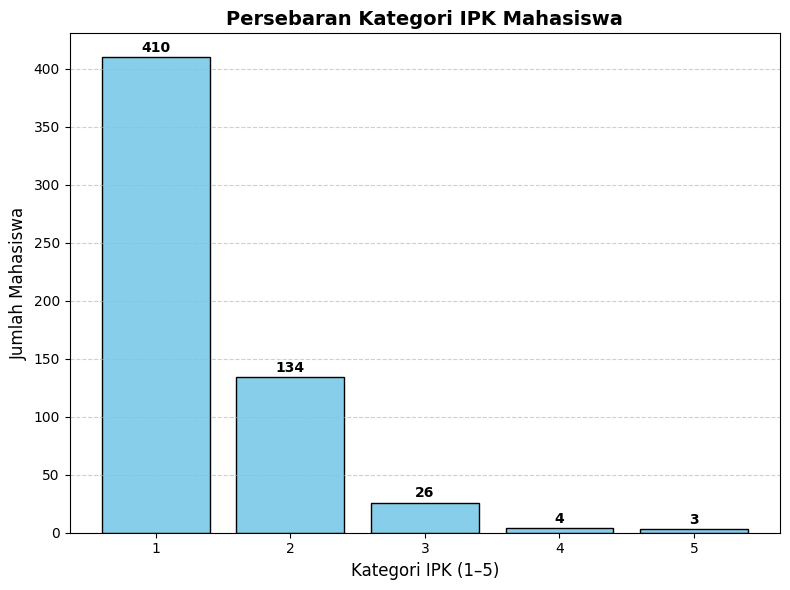

In [4]:
# jumlah mahasiswa/kategori IPK
gpa_counts = df['Cumulative average (GPA)'].value_counts().sort_index().reset_index()
gpa_counts.columns = ['Kategori IPK', 'Jumlah Mahasiswa']

plt.figure(figsize=(8,6))
bars = plt.bar(gpa_counts['Kategori IPK'], gpa_counts['Jumlah Mahasiswa'], color='skyblue', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, yval + 2,
        int(yval), ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.title('Persebaran Kategori IPK Mahasiswa', fontsize=14, fontweight='bold')
plt.xlabel('Kategori IPK (1–5)', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [5]:
# Cek tipe data dan jumlah nilai kosong
df.info()
print("\nJumlah nilai kosong per kolom:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Faculty                        577 non-null    int64
 1   Gender                         577 non-null    int64
 2   Academic year                  577 non-null    int64
 3   Age group                      577 non-null    int64
 4   Learning time before COVID-19  577 non-null    int64
 5   Learning time during COVID-19  577 non-null    int64
 6   No. of Siblings                577 non-null    int64
 7   Location of residence          577 non-null    int64
 8   Source of tuition fees         577 non-null    int64
 9   Cumulative average (GPA)       577 non-null    int64
 10  Daily Internet usage           577 non-null    int64
 11  Purpose of internet usage      577 non-null    int64
 12  Devices often use              577 non-null    int64
 13  Parental education  

In [6]:
ordinal_cols = [
    'Age group', 'Academic year', 'Cumulative average (GPA)',
    'Daily Internet usage', 'Learning time before COVID-19',
    'Learning time during COVID-19', 'Parental education', 'No. of Siblings'
]

nominal_cols = [
    'Faculty', 'Gender', 'Location of residence',
    'Source of tuition fees ', 'Devices often use', 'Parental occupation'
]

# encode nominal
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# encode ordonal
ord_enc = OrdinalEncoder()
df_encoded[ordinal_cols] = ord_enc.fit_transform(df_encoded[ordinal_cols])

df_encoded.head()

,Academic year,Age group,Learning time before COVID-19,Learning time during COVID-19,No. of Siblings,Cumulative average (GPA),Daily Internet usage,Purpose of internet usage,Parental education,GS1,...,Location of residence_3,Source of tuition fees _2,Source of tuition fees _3,Devices often use_2,Devices often use_3,Devices often use_4,Parental occupation_2,Parental occupation_3,Parental occupation_4,Parental occupation_5
0,1.0,0.0,1.0,1.0,0.0,0.0,2.0,3,1.0,4,...,True,False,False,True,False,False,False,False,True,False
1,0.0,0.0,0.0,0.0,3.0,0.0,1.0,3,1.0,5,...,True,True,False,True,False,False,False,False,False,False
2,1.0,0.0,1.0,0.0,1.0,0.0,2.0,3,1.0,4,...,True,False,False,True,False,False,False,False,True,False
3,2.0,1.0,1.0,1.0,2.0,0.0,2.0,3,1.0,4,...,True,False,False,False,True,False,False,False,True,False
4,1.0,1.0,1.0,0.0,2.0,1.0,1.0,3,1.0,4,...,False,False,False,False,True,False,False,False,True,False


In [7]:
oslq_cols = [col for col in df_encoded.columns if col.startswith(('GS', 'EH', 'TS', 'TM', 'HR', 'SE'))]
print("Kolom OSLQ:", oslq_cols)

# scaling
scaler = MinMaxScaler()

# Fit dan transform kolom OSLQ
df_encoded[oslq_cols] = scaler.fit_transform(df[oslq_cols])

# Sebelum scaling
print("Nilai sebelum scaling:")
print(df[oslq_cols].describe())

# Sesudah scaling
print("\nNilai sesudah scaling:")
print(df_encoded[oslq_cols].describe())

Kolom OSLQ: ['GS1', 'GS2', 'GS3', 'GS4', 'GS5', 'TS1', 'TS2', 'TS3', 'TS4', 'TM1', 'TM2', 'TM3', 'SE1', 'SE2', 'SE3', 'SE4']
Nilai sebelum scaling:
              GS1         GS2         GS3         GS4         GS5         TS1  \
count  577.000000  577.000000  577.000000  577.000000  577.000000  577.000000   
mean     4.102253    3.970537    3.679376    4.143847    3.792028    3.880416   
std      0.675677    0.777839    0.916368    0.730131    0.974540    0.913583   
min      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   
25%      4.000000    4.000000    3.000000    4.000000    3.000000    3.000000   
50%      4.000000    4.000000    4.000000    4.000000    4.000000    4.000000   
75%      5.000000    4.000000    4.000000    5.000000    4.000000    5.000000   
max      5.000000    5.000000    5.000000    5.000000    5.000000    5.000000   

              TS2         TS3         TS4         TM1         TM2         TM3  \
count  577.000000  577.000000  577.000000

In [8]:
df_encoded[oslq_cols].head()

,GS1,GS2,GS3,GS4,GS5,TS1,TS2,TS3,TS4,TM1,TM2,TM3,SE1,SE2,SE3,SE4
0,0.75,0.75,0.75,0.75,0.75,0.50,0.50,0.50,0.50,0.75,0.50,0.75,0.75,0.75,0.50,0.75
1,1.00,1.00,0.25,0.25,0.25,0.25,0.25,0.25,0.25,0.25,1.00,1.00,0.25,0.25,0.25,0.75
2,0.75,0.75,0.75,0.75,0.50,0.75,0.75,0.50,0.50,0.75,0.75,0.75,0.50,0.75,0.75,0.75
3,0.75,0.75,0.75,0.75,0.25,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75
4,0.75,0.50,0.25,0.75,0.75,1.00,0.00,0.25,0.50,0.25,0.25,0.50,0.75,0.75,0.00,0.25


In [9]:
X = df_encoded.drop(columns=['Cumulative average (GPA)'])
y = df_encoded['Cumulative average (GPA)']

print("jumlah fitur: ", X.shape[1])

jumlah fitur:  51


In [10]:
# Membagi data menjadi train (80%) dan test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

label_mapping = {
    0.0: "3.5+",
    1.0: "3.0–3.49",
    2.0: "2.5–2.99",
    3.0: "2.0–2.49",
    4.0: "<2.0"
}

# Menampilkan hasil split
print("Jumlah data latih :", X_train.shape[0])
print("Jumlah data uji    :", X_test.shape[0])
print("Proporsi kelas di data latih:\n", y_train.replace(label_mapping).value_counts(normalize=True))
print("\nProporsi kelas di data uji:\n", y_test.replace(label_mapping).value_counts(normalize=True))

Jumlah data latih : 461
Jumlah data uji    : 116
Proporsi kelas di data latih:
 Cumulative average (GPA)
3.5+        0.711497
3.0–3.49    0.232104
2.5–2.99    0.045553
2.0–2.49    0.006508
<2.0        0.004338
Name: proportion, dtype: float64

Proporsi kelas di data uji:
 Cumulative average (GPA)
3.5+        0.706897
3.0–3.49    0.232759
2.5–2.99    0.043103
2.0–2.49    0.008621
<2.0        0.008621
Name: proportion, dtype: float64


In [11]:
# Inisialisasi SMOTE
smote = SMOTE(random_state=42, k_neighbors=1)

# Terapkan SMOTE hanya pada data training
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Tampilkan distribusi dengan label kategori
print("Distribusi sebelum SMOTE (kategori):")
print(y_train.replace(label_mapping).value_counts())

print("\nDistribusi sesudah SMOTE (kategori):")
print(y_train_resampled.replace(label_mapping).value_counts())

Distribusi sebelum SMOTE (kategori):
Cumulative average (GPA)
3.5+        328
3.0–3.49    107
2.5–2.99     21
2.0–2.49      3
<2.0          2
Name: count, dtype: int64

Distribusi sesudah SMOTE (kategori):
Cumulative average (GPA)
3.5+        328
3.0–3.49    328
2.5–2.99    328
2.0–2.49    328
<2.0        328
Name: count, dtype: int64


In [12]:
# fungsi gini index
def gini_index(groups, classes):
    n_instances = float(sum([len(group) for group in groups]))
    gini = 0.0
    for group in groups:
        size = float(len(group))
        if size == 0:
            continue
        score = 0.0
        class_values = [row[-1] for row in group]
        for class_val in classes:
            p = class_values.count(class_val) / size
            score += p * p
        gini += (1.0 - score) * (size / n_instances)
    return gini

In [13]:
def test_split(index, value, dataset):
    left, right = [], []
    for row in dataset:
        if row[index] < value:
            left.append(row)
        else:
            right.append(row)
    return left, right

In [14]:
# fungsi split data
def get_split(dataset):
    class_values = list(set(row[-1] for row in dataset))
    b_index, b_value, b_score, b_groups = 999, 999, 999, None
    for index in range(len(dataset[0]) - 1):
        for row in dataset:
            groups = test_split(index, row[index], dataset)
            gini = gini_index(groups, class_values)
            if gini < b_score:
                b_index, b_value, b_score, b_groups = index, row[index], gini, groups
    return {'index': b_index, 'value': b_value, 'groups': b_groups}

In [15]:
# fungsi node terminal
def to_terminal(group):
    outcomes = [row[-1] for row in group]
    return max(set(outcomes), key=outcomes.count)

In [16]:
# fungsi split node rekursif
def split(node, max_depth, min_size, depth):
    left, right = node['groups']
    del(node['groups'])

    # jika salah satu sisi kosong -> buat leaf
    if not left or not right:
        outcomes = [row[-1] for row in left + right]
        node['left'] = node['right'] = max(set(outcomes), key=outcomes.count)
        return

    # stop jika kedalaman maksimum
    if depth >= max_depth:
        node['left'], node['right'] = to_terminal(left), to_terminal(right)
        return

    # split sisi kiri dan kanan
    if len(left) <= min_size:
        node['left'] = to_terminal(left)
    else:
        node['left'] = get_split_rf(left, n_features)
        # ⬇ tambahkan ini supaya gain tersimpan di semua node bawah
        split(node['left'], max_depth, min_size, depth + 1)

    if len(right) <= min_size:
        node['right'] = to_terminal(right)
    else:
        node['right'] = get_split_rf(right, n_features)
        # ⬇ sama, recursive untuk kanan
        split(node['right'], max_depth, min_size, depth + 1)

In [17]:
# fungsi build tree
def build_tree(train, max_depth, min_size):
    root = get_split(train)
    split(root, max_depth, min_size, 1)
    return root

In [18]:
# fungsi predict
def predict(node, row):
    if row[node['index']] < node['value']:
        if isinstance(node['left'], dict):
            return predict(node['left'], row)
        else:
            return node['left']
    else:
        if isinstance(node['right'], dict):
            return predict(node['right'], row)
        else:
            return node['right']

In [19]:
# pipeline & testing
def decision_tree(train, test, max_depth, min_size):
    tree = build_tree(train, max_depth, min_size)
    predictions = [predict(tree, row) for row in test]
    return predictions

In [20]:
# fungsi bootstrap sample
def subsample(dataset, ratio):
    sample_size = round(len(dataset) * ratio)
    sample_data = []
    while len(sample_data) < sample_size:
        index = randrange(len(dataset))
        sample_data.append(dataset[index])
    return sample_data

In [21]:
# get_split_rf dengan Gini Gain
def get_split_rf(dataset, n_features):
    class_values = list(set(row[-1] for row in dataset))
    features = sample(range(len(dataset[0]) - 1), n_features)
    b_index, b_value, b_score, b_groups, best_gain = 999, 999, 999, None, 0

    current_gini = gini_index([dataset], class_values)

    for index in features:
        for row in dataset:
            groups = test_split(index, row[index], dataset)
            gini_after = gini_index(groups, class_values)
            gain = current_gini - gini_after  # impurity reduction

            if gini_after < b_score:
                b_index, b_value, b_score, b_groups, best_gain = index, row[index], gini_after, groups, gain

    return {
        'index': b_index,
        'value': b_value,
        'groups': b_groups,
        'gain': best_gain
    }


In [22]:
# build tree dengan split_rf
def build_tree_rf(train, max_depth, min_size, n_features):
    root = get_split_rf(train, n_features)
    split(root, max_depth, min_size, 1)
    return root

In [23]:
# Pindahkan fungsi build_one_tree global
def build_one_tree(train, max_depth, min_size, sample_size, n_features):
    sample = subsample(train, sample_size)
    tree = build_tree_rf(sample, max_depth, min_size, n_features)
    return tree

In [24]:
def build_forest_parallel(train, max_depth, min_size, sample_size, n_trees, n_features, n_jobs=-1):
    print(f" Membangun {n_trees} pohon secara paralel ({n_jobs if n_jobs != -1 else 'semua CPU'} core aktif)")

    # Gunakan tqdm untuk progress bar per pohon
    results = Parallel(n_jobs=n_jobs)(
        delayed(build_tree_rf)(subsample(train, sample_size), max_depth, min_size, n_features)
        for _ in tqdm(range(n_trees), desc="Building Trees", ncols=80)
    )

    print(f" Semua {n_trees} pohon selesai dibangun!")
    return results

In [25]:
# voting
def bagging_predict(trees, row):
    predictions = [predict(tree, row) for tree in trees]
    return max(set(predictions), key=predictions.count)

In [26]:
# pipeline random forest
def random_forest(train, test, max_depth, min_size, sample_size, n_trees, n_features, n_jobs=None):
    forest = build_forest_parallel(train, max_depth, min_size, sample_size, n_trees, n_features, n_jobs)
    predictions = [bagging_predict(forest, row) for row in test]
    return predictions

In [27]:
# Gabungkan fitur dan target jadi satu dataset
train_data = [list(X_train_resampled.iloc[i]) + [y_train_resampled.iloc[i]] for i in range(len(X_train_resampled))]
test_data = [list(X_test.iloc[i]) + [y_test.iloc[i]] for i in range(len(X_test))]

In [28]:
# logistic regression (base model)
# fungsi Sigmoid
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

In [29]:
# Prediksi satu baris data
def predict_logreg(row, weights):
    z = weights[0]
    for i in range(len(row) - 1):
        z += weights[i + 1] * row[i]
    return sigmoid(z)

In [30]:
# Training Logistic Regression
def train_logistic_regression(train, l_rate, n_epoch, patience=100, min_delta=0.01):
    weights = [0.0 for _ in range(len(train[0]))]
    error_history = []
    best_error = float('inf')
    no_improve = 0

    for epoch in range(n_epoch):
        sum_error = 0
        for row in train:
            yhat = predict_logreg(row, weights)
            error = row[-1] - yhat
            sum_error += error ** 2
            weights[0] += l_rate * error * yhat * (1.0 - yhat)
            for i in range(len(row)-1):
                weights[i + 1] += l_rate * error * yhat * (1.0 - yhat) * row[i]

        error_history.append(sum_error)

        # Cetak progress tiap 100 epoch
        if epoch % 100 == 0:
            print(f"Epoch={epoch}, Error={sum_error:.3f}")

        # Early stopping logic
        if sum_error < best_error - min_delta:
            best_error = sum_error
            no_improve = 0
        else:
            no_improve += 1

        # Stop kalau error gak turun dalam 'patience' epoch
        if no_improve >= patience:
            print(f"  Early stopping di epoch {epoch} (error tidak membaik selama {patience} epoch).")
            break

    return weights, error_history

In [31]:
# Prediksi Logistic Regression
def logistic_regression(train, test, l_rate, n_epoch, patience=100, min_delta=0.01, return_weights=False):
    weights, error_history = train_logistic_regression(
        train, l_rate, n_epoch,
        patience=patience, min_delta=min_delta
    )
    
    predictions = [round(predict_logreg(row, weights)) for row in test]

    if return_weights:
        return predictions, error_history, weights
    else:
        return predictions, error_history

In [32]:
def predict_multiclass(test, models):
    predictions = []
    for row in test:
        probs = [predict_logreg(row, weights) for weights in models]
        predictions.append(probs.index(max(probs)))
    return predictions

In [33]:
# Fungsi OvR Multi-class Logistic Regression (paralel + early stopping + error tracking)
def logistic_regression_multiclass(train, test, n_classes, l_rate, n_epoch, n_jobs=4, patience=100, min_delta=0.01):
    """
    Multi-class Logistic Regression (One-vs-Rest) dengan:
    - Early stopping berdasarkan error
    - Paralel training menggunakan joblib
    - Tracking error tiap kelas
    """
    error_histories = []  # simpan semua history error untuk tiap kelas

    def train_one_vs_rest(class_val):
        # ubah label ke binary: 1 kalau row[-1] == class_val, 0 kalau bukan
        train_binary = []
        for row in train:
            new_row = list(row)
            new_row[-1] = 1.0 if row[-1] == class_val else 0.0
            train_binary.append(new_row)

        # latih logistic regression dengan early stopping
        weights, err_hist = train_logistic_regression(
            train_binary, l_rate, n_epoch,
            patience=patience, min_delta=min_delta
        )
        return weights, err_hist

    print(f" Melatih {n_classes} model Logistic Regression secara paralel (dengan early stopping)...")

    # training paralel dengan joblib
    results = Parallel(n_jobs=n_jobs)(
        delayed(train_one_vs_rest)(class_val)
        for class_val in tqdm(range(n_classes), desc="Training OvR Models", ncols=80)
    )

    # pisahkan hasil training (weights dan error histories)
    models = [r[0] for r in results]
    error_histories = [r[1] for r in results]

    print(" Semua model OvR selesai dilatih!\n")

    return models, error_histories

In [34]:
# Parameter Random Forest
n_trees =128
max_depth = 10
min_size = 5
sample_size = 1.0
n_features = int(sqrt(len(X_train_resampled.columns)))

In [35]:
# Base Model 1: Random Forest (Paralel)
forest = build_forest_parallel(
    train_data, 
    max_depth, 
    min_size, 
    sample_size, 
    n_trees, 
    n_features, 
    n_jobs=4  
)

# Prediksi untuk data train dan test
y_pred_rf_train = [bagging_predict(forest, row) for row in train_data]
y_pred_rf_test  = [bagging_predict(forest, row) for row in test_data]

 Membangun 128 pohon secara paralel (4 core aktif)


Building Trees: 100%|█████████████████████████| 128/128 [17:19<00:00,  8.12s/it]


 Semua 128 pohon selesai dibangun!


In [36]:
# Base Model 2: Logistic Regression (One-vs-Rest Multi-class)
# Gabungkan data training & testing ke format list
train_logreg = [list(X_train_resampled.iloc[i]) + [y_train_resampled.iloc[i]] for i in range(len(X_train_resampled))]
test_logreg  = [list(X_test.iloc[i]) + [y_test.iloc[i]] for i in range(len(X_test))]

# Jumlah kelas (IPK 0–4)
n_classes = 5

# Latih Logistic Regression OvR (sekali saja)
models, train_error_histories = logistic_regression_multiclass(
    train_logreg,
    train_logreg,
    n_classes,
    l_rate=0.001,
    n_epoch=2000,
    patience=100,
    min_delta=0.01,
    n_jobs=4
)

# Prediksi train dan test dengan model hasil training
y_pred_logreg_train = predict_multiclass(train_logreg, models)
y_pred_logreg_test  = predict_multiclass(test_logreg, models)

# Cek error histories tiap kelas
for i, history in enumerate(train_error_histories):
    print(f" Class {i} | Epochs = {len(history)} | Final Error = {history[-1]:.4f}")


 Melatih 5 model Logistic Regression secara paralel (dengan early stopping)...


Training OvR Models: 100%|███████████████████████| 5/5 [00:00<00:00, 308.62it/s]


 Semua model OvR selesai dilatih!

 Class 0 | Epochs = 2000 | Final Error = 90.1104
 Class 1 | Epochs = 2000 | Final Error = 95.0761
 Class 2 | Epochs = 2000 | Final Error = 35.7238
 Class 3 | Epochs = 2000 | Final Error = 0.8353
 Class 4 | Epochs = 2000 | Final Error = 0.2980


In [37]:
# Buat Meta Dataset (gabungan hasil prediksi dua base model)
meta_train = [[y_pred_rf_train[i], y_pred_logreg_train[i], y_train_resampled.iloc[i]] for i in range(len(y_train_resampled))]
meta_test  = [[y_pred_rf_test[i], y_pred_logreg_test[i], y_test.iloc[i]] for i in range(len(y_test))]

# Jumlah kelas target IPK (1–5)
n_classes = 5

# Meta Learner: Logistic Regression (Multi-class OvR) dengan Early Stopping
meta_models, meta_error_histories = logistic_regression_multiclass(
    train=meta_train,
    test=None,
    n_classes=n_classes,
    l_rate=0.001,
    n_epoch=2000,
    patience=100,
    min_delta=0.01,
    n_jobs=4
)

# Prediksi hasil meta learner (pakai model yang sama)
y_pred_final = predict_multiclass(meta_test, meta_models)

# Cek isi error histories (jumlah epoch yang dijalankan tiap kelas)
for i, history in enumerate(meta_error_histories):
    print(f" Class {i} | Epochs = {len(history)} | Final Error = {history[-1]:.4f}")

# Evaluasi manual akurasi model hybrid
actual = [row[-1] for row in meta_test]
correct = sum(1 for i in range(len(actual)) if actual[i] == y_pred_final[i])
accuracy = correct / float(len(actual)) * 100.0

print(f"\n Akurasi Model Hybrid (RF + LogReg OvR): {accuracy:.2f}%")


 Melatih 5 model Logistic Regression secara paralel (dengan early stopping)...


Training OvR Models: 100%|██████████████████████| 5/5 [00:00<00:00, 2492.16it/s]


 Semua model OvR selesai dilatih!

 Class 0 | Epochs = 2000 | Final Error = 12.1117
 Class 1 | Epochs = 2000 | Final Error = 226.1777
 Class 2 | Epochs = 1027 | Final Error = 259.7980
 Class 3 | Epochs = 578 | Final Error = 237.3305
 Class 4 | Epochs = 2000 | Final Error = 18.5283

 Akurasi Model Hybrid (RF + LogReg OvR): 75.00%


In [38]:
# Ubah meta_train & meta_test ke bentuk dataframe
meta_train_df = pd.DataFrame(meta_train, columns=["RF_Pred", "LogReg_Pred", "Actual"])
meta_test_df = pd.DataFrame(meta_test, columns=["RF_Pred", "LogReg_Pred", "Actual"])

# Tampilkan baris awal
print("=== Meta Train ===")
print(meta_train_df.head())

print("\n=== Meta Test ===")
print(meta_test_df.head())

# Distribusi label pada meta dataset
print("\nDistribusi kelas aktual (Train):")
print(meta_train_df["Actual"].value_counts())

print("\nDistribusi kelas aktual (Test):")
print(meta_test_df["Actual"].value_counts())

# Opsional: frekuensi kombinasi prediksi base model
print("\nKombinasi unik prediksi RF dan LogReg (Train):")
print(meta_train_df.groupby(["RF_Pred", "LogReg_Pred"]).size().reset_index(name="count"))

=== Meta Train ===
   RF_Pred  LogReg_Pred  Actual
0      0.0            0     0.0
1      1.0            1     1.0
2      0.0            0     0.0
3      1.0            1     1.0
4      0.0            0     0.0

=== Meta Test ===
   RF_Pred  LogReg_Pred  Actual
0      0.0            0     0.0
1      0.0            2     1.0
2      0.0            0     0.0
3      0.0            0     0.0
4      0.0            0     0.0

Distribusi kelas aktual (Train):
Actual
0.0    328
1.0    328
2.0    328
3.0    328
4.0    328
Name: count, dtype: int64

Distribusi kelas aktual (Test):
Actual
0.0    82
1.0    27
2.0     5
3.0     1
4.0     1
Name: count, dtype: int64

Kombinasi unik prediksi RF dan LogReg (Train):
    RF_Pred  LogReg_Pred  count
0       0.0            0    268
1       0.0            1     61
2       0.0            2      9
3       0.0            3      2
4       0.0            4      1
5       1.0            0     30
6       1.0            1    269
7       1.0            2     22
8   

In [39]:
# evaluasi model

ipk_labels = ["3.5+", "3.0–3.49", "2.5–2.99", "2.0–2.49", "<2.0"]
def evaluate_model(y_true, y_pred, model_name="Model", labels_custom=None, normalize=False):
    print(f"\n=== {model_name} Evaluation ===")
    print(f"Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%\n")

    # Tentukan label yang dipakai
    classes = sorted(list(set(y_true)))
    if labels_custom and len(labels_custom) == len(classes):
        tick_labels = labels_custom
    else:
        tick_labels = classes

    # === Classification Report ===
    if labels_custom and len(labels_custom) == len(classes):
        print("Classification Report:")
        print(classification_report(y_true, y_pred, target_names=labels_custom, digits=2))
    else:
        print("Classification Report:")
        print(classification_report(y_true, y_pred, digits=2))

    # === Confusion Matrix ===
    cm = confusion_matrix(y_true, y_pred, labels=classes, normalize='true' if normalize else None)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap="Blues",
                xticklabels=tick_labels, yticklabels=tick_labels)
    plt.title(f"Confusion Matrix - {model_name}\n{'(Normalized)' if normalize else ''}", fontsize=14, pad=10)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("Actual Label", fontsize=12)
    plt.tight_layout()
    plt.show()


=== Random Forest Evaluation ===
Accuracy: 74.14%

Classification Report:
              precision    recall  f1-score   support

        3.5+       0.75      0.98      0.85        82
    3.0–3.49       0.67      0.22      0.33        27
    2.5–2.99       0.00      0.00      0.00         5
    2.0–2.49       0.00      0.00      0.00         1
        <2.0       0.00      0.00      0.00         1

    accuracy                           0.74       116
   macro avg       0.28      0.24      0.24       116
weighted avg       0.69      0.74      0.68       116



c:\Users\Coretail\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Coretail\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Coretail\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

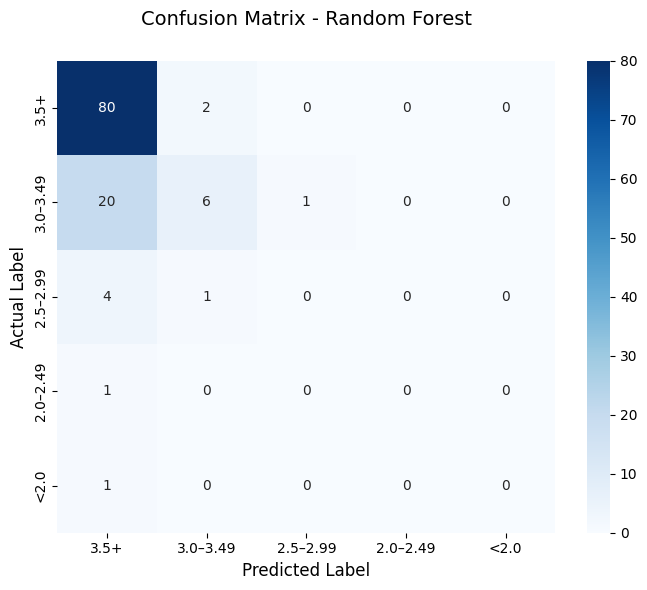

In [40]:
# evaluasi random forest
actual_rf = [row[-1] for row in test_data]
evaluate_model(actual_rf, y_pred_rf_test, model_name="Random Forest", labels_custom=ipk_labels)


=== Logistic Regression Evaluation ===
Accuracy: 66.38%

Classification Report:
              precision    recall  f1-score   support

        3.5+       0.83      0.78      0.81        82
    3.0–3.49       0.46      0.41      0.43        27
    2.5–2.99       0.15      0.40      0.22         5
    2.0–2.49       0.00      0.00      0.00         1
        <2.0       0.00      0.00      0.00         1

    accuracy                           0.66       116
   macro avg       0.29      0.32      0.29       116
weighted avg       0.70      0.66      0.68       116



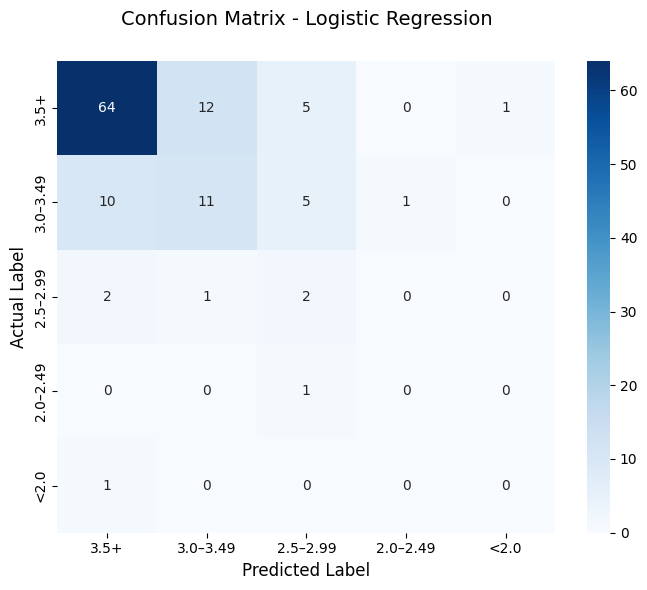

In [41]:
# evaluasi logistic regression
actual_lr = [row[-1] for row in test_logreg]
evaluate_model(actual_lr, y_pred_logreg_test, model_name="Logistic Regression", labels_custom=ipk_labels)


=== Hybrid (RF + LogReg) Evaluation ===
Accuracy: 75.00%

Classification Report:
              precision    recall  f1-score   support

        3.5+       0.75      0.98      0.85        82
    3.0–3.49       0.70      0.26      0.38        27
    2.5–2.99       0.00      0.00      0.00         5
    2.0–2.49       0.00      0.00      0.00         1
        <2.0       0.00      0.00      0.00         1

    accuracy                           0.75       116
   macro avg       0.29      0.25      0.25       116
weighted avg       0.70      0.75      0.69       116



c:\Users\Coretail\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Coretail\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Coretail\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

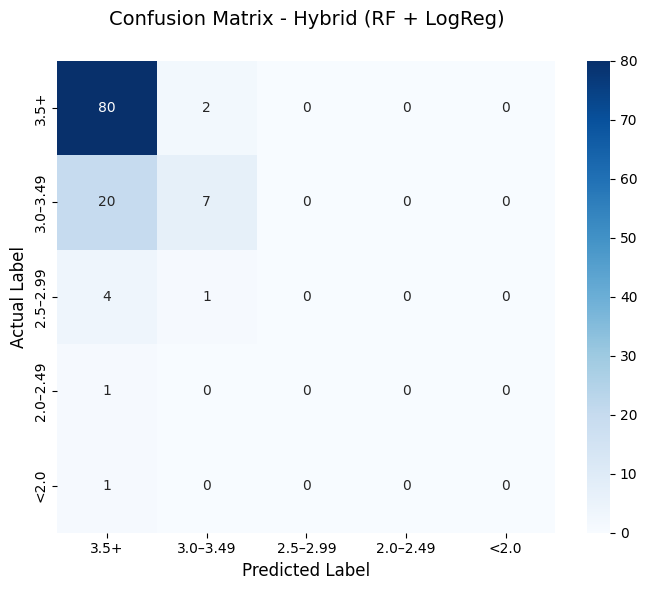

In [42]:
# evaluasi hybrid
actual_hybrid = [row[-1] for row in meta_test]
evaluate_model(actual_hybrid, y_pred_final, model_name="Hybrid (RF + LogReg)", labels_custom=ipk_labels)

In [43]:
# Random forest feature importance (base model 1)

def compute_rf_feature_importance(forest, n_total_features):
    importance = np.zeros(n_total_features)
    
    def traverse(node):
        if isinstance(node, dict):
            idx = node['index']
            gain = node.get('gain', 0)
            importance[idx] += gain
            traverse(node['left'])
            traverse(node['right'])
    
    for tree in forest:
        traverse(tree)
    
    total = np.sum(importance)
    if total > 0:
        importance /= total
    return importance


In [44]:

# feature importance (base model 2)

def compute_logreg_feature_importance(models, feature_names=None):
    """Hitung importance rata-rata dari semua model OvR Logistic Regression"""
    # Ambil bobot tiap model OvR (models berisi list of weights)
    weights = np.array([np.abs(model[1:]) for model in models])  # skip bias di index 0
    mean_importance = np.mean(weights, axis=0)

    # Normalisasi
    mean_importance /= np.sum(mean_importance)

    print("\nFeature Importance (Logistic Regression OvR):")
    if feature_names is not None:
        for name, imp in zip(feature_names, mean_importance):
            print(f"{name:<25} → {imp:.4f}")
    else:
        for i, imp in enumerate(mean_importance):
            print(f"Feature {i+1}: {imp:.4f}")

    return mean_importance

In [45]:
# ambil feature importance
rf_importance = compute_rf_feature_importance(forest, len(X_train_resampled.columns))
# Buat array nama fitur & importance
feature_names = np.array(X_train_resampled.columns)
importances = np.array(rf_importance)

# Urutkan dari terbesar ke terkecil
sorted_idx = np.argsort(importances)[::-1]
sorted_features = feature_names[sorted_idx]
sorted_importances = importances[sorted_idx]

# Cetak hasil terurut
print("\n Feature Importance (Random Forest) — Diurutkan:")
for f, imp in zip(sorted_features, sorted_importances):
    print(f"{f:<30} → {imp:.4f}")


 Feature Importance (Random Forest) — Diurutkan:
No. of Siblings                → 0.0353
GS5                            → 0.0352
Faculty_6                      → 0.0326
TS3                            → 0.0309
Learning time during COVID-19  → 0.0300
TS4                            → 0.0299
HS1                            → 0.0294
GS3                            → 0.0288
GS2                            → 0.0281
SE4                            → 0.0279
HS4                            → 0.0274
Academic year                  → 0.0273
SE3                            → 0.0266
SE1                            → 0.0254
TS2                            → 0.0253
TM2                            → 0.0253
TS1                            → 0.0250
Parental education             → 0.0248
HS2                            → 0.0242
Learning time before COVID-19  → 0.0235
TM1                            → 0.0233
SE2                            → 0.0232
TM3                            → 0.0231
HS3                           

In [46]:
# Ambil hasil importance
logreg_importance = compute_logreg_feature_importance(models, X_train_resampled.columns)
# Urutkan dari yang terbesar ke terkecil
sorted_features = sorted(
    zip(X_train_resampled.columns, logreg_importance),
    key=lambda x: x[1],
    reverse=True
)

print("\n🌟 Feature Importance (Logistic Regression OvR) - Diurutkan:")
for name, imp in sorted_features:
    print(f"{name:<25} → {imp:.4f}")



Feature Importance (Logistic Regression OvR):
Academic year             → 0.0126
Age group                 → 0.0142
Learning time before COVID-19 → 0.0056
Learning time during COVID-19 → 0.0184
No. of Siblings           → 0.0165
Daily Internet usage      → 0.0256
Purpose of internet usage → 0.0202
Parental education        → 0.0105
GS1                       → 0.0065
GS2                       → 0.0149
GS3                       → 0.0112
GS4                       → 0.0069
GS5                       → 0.0252
ES1                       → 0.0130
ES2                       → 0.0114
ES3                       → 0.0250
ES4                       → 0.0085
TS1                       → 0.0137
TS2                       → 0.0129
TS3                       → 0.0085
TS4                       → 0.0301
TM1                       → 0.0177
TM2                       → 0.0053
TM3                       → 0.0092
HS1                       → 0.0111
HS2                       → 0.0160
HS3                       → 0.0146


In [56]:
def compute_meta_feature_importance(meta_models, feature_names=None):
    """
    Menghitung rata-rata absolut bobot dari model meta-learner (OvR Logistic Regression)
    untuk melihat kontribusi masing-masing base model.
    """
    # Ambil bobot tiap model (kecuali bias di indeks 0)
    weights = np.array([np.abs(model[1:]) for model in meta_models])  # shape: [n_classes, n_features]
    
    # Hitung rata-rata per fitur di seluruh kelas
    mean_importance = np.mean(weights, axis=0)
    
    # Normalisasi agar total = 1
    mean_importance /= np.sum(mean_importance)
    
    # Tampilkan hasil
    print("Feature Importance (Meta Learner: RF vs LogReg):")
    if feature_names is not None:
        for name, imp in zip(feature_names, mean_importance):
            print(f"{name:<25} : {imp:.4f}")
    else:
        for i, imp in enumerate(mean_importance):
            print(f"Feature {i+1:<2} : {imp:.4f}")
    
    return mean_importance


In [57]:
meta_feature_names = ["Random Forest Prediction", "Logistic Regression Prediction"]

meta_importance = compute_meta_feature_importance(meta_models, meta_feature_names)

Feature Importance (Meta Learner: RF vs LogReg):
Random Forest Prediction  : 0.6449
Logistic Regression Prediction : 0.3551


In [59]:
# Buat array nama fitur & importance
feature_names = np.array(X_train_resampled.columns)
importances = np.array(rf_importance)

# Urutkan dari yang terbesar ke terkecil
sorted_idx = np.argsort(importances)[::-1]
sorted_features = feature_names[sorted_idx]
sorted_importances = importances[sorted_idx]

# Ambil hanya 10 teratas
top_n = 10
sorted_features = sorted_features[:top_n]
sorted_importances = sorted_importances[:top_n]

# Cetak hasil
print("Feature Importance (Random Forest) — 10 Teratas:")
for f, imp in zip(sorted_features, sorted_importances):
    print(f"{f:<30} : {imp:.4f}")


Feature Importance (Random Forest) — 10 Teratas:
No. of Siblings                : 0.0353
GS5                            : 0.0352
Faculty_6                      : 0.0326
TS3                            : 0.0309
Learning time during COVID-19  : 0.0300
TS4                            : 0.0299
HS1                            : 0.0294
GS3                            : 0.0288
GS2                            : 0.0281
SE4                            : 0.0279


In [58]:
# Urutkan dari yang terbesar ke terkecil
sorted_features = sorted(
    zip(X_train_resampled.columns, logreg_importance),
    key=lambda x: x[1],
    reverse=True
)[:10]  # ambil 10 teratas

print("Feature Importance (Logistic Regression OvR) — 10 Teratas:")
for name, imp in sorted_features:
    print(f"{name:<25} : {imp:.4f}")

Feature Importance (Logistic Regression OvR) — 10 Teratas:
Faculty_4                 : 0.0673
Faculty_6                 : 0.0470
Devices often use_3       : 0.0423
Devices often use_4       : 0.0371
Parental occupation_4     : 0.0354
Parental occupation_5     : 0.0327
Parental occupation_2     : 0.0311
TS4                       : 0.0301
Devices often use_2       : 0.0295
Faculty_8                 : 0.0291
